In [ ]:
# notebook to figure out what the hell is going on with COSMIC
# we have:
# cosmic bed file (unfiltered)
# gencode + splice pad (stephen)
# gencode exons only (stephen)
# splice pad only ( (gencode + splice pad) - (gencode exons only) )
# exons in our file should only be for canonical, protein coding genes

In [1]:
# import packages
import pprint
import pandas as pd
import pybedtools
import os
import requests
import time
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
### WAS USING BASIC ANNOTATION SET - CONVERT TO PROTEIN CODING ONLY ###

In [3]:
# store path to raw gencode file as a variable for checking
gencode_v44 = '/projects/tewhey-lab/buttsj/genomes/gencode.v44.basic.annotation.gff3.gz'

In [4]:
# open each bed file
# cosmic variants
cosmic_bed = pybedtools.BedTool('../processed_data/all.cosmic.v98.autosome.with.10bp.indels.bed')
# exons + pad
#exonsWithPad_basic = pybedtools.BedTool('../raw_data/gencode.v44.basic.annotation.exons.splice.autosomes.v2.093025.bed')
exonsWithPad_proteinCoding = pybedtools.BedTool('../raw_data/gencode.v44.protein.coding.exons.splice.autosomes.v2.bed')
# exons only
#exonsNoPad_basic = pybedtools.BedTool('../raw_data/gencode.v44.basic.annotation.exons.autosomes.v2.bed')
exonsNoPad_proteinCoding = pybedtools.BedTool('../raw_data/gencode.v44.protein.coding.exons.autosomes.v2.bed')
# pad only
#padOnly_basic = pybedtools.BedTool('../raw_data/gencode.v44.basic.annotation.exons.splice.pad.v2.bed')
padOnly_proteinCoding = pybedtools.BedTool('../raw_data/gencode.v44.protein.coding.exons.splice.pad.v2.bed')
#### updated bed ####
newBed = pybedtools.BedTool('../raw_data/gencode.v44.protein.coding.exons.autosomes.canonical.annotated.bed')

In [19]:
newBed.to_dataframe().loc[100:150,:]

,chrom,start,end,name,score,strand,thickStart,thickEnd,itemRgb,blockCount
100,chr1,1049235,1049451,AGRN,0,+,ENSG00000188157.15,ENST00000379370.7,ENSE00001706121.1,25
101,chr1,1049565,1049795,AGRN,0,+,ENSG00000188157.15,ENST00000379370.7,ENSE00001622861.1,26
102,chr1,1049902,1050037,AGRN,0,+,ENSG00000188157.15,ENST00000379370.7,ENSE00001756488.1,27
103,chr1,1050232,1050329,AGRN,0,+,ENSG00000188157.15,ENST00000379370.7,ENSE00001657020.1,28
104,chr1,1050426,1050591,AGRN,0,+,ENSG00000188157.15,ENST00000379370.7,ENSE00001693596.1,29
105,chr1,1050725,1050837,AGRN,0,+,ENSG00000188157.15,ENST00000379370.7,ENSE00001367302.1,30
106,chr1,1051252,1051369,AGRN,0,+,ENSG00000188157.15,ENST00000379370.7,ENSE00001385905.1,31
107,chr1,1051452,1051645,AGRN,0,+,ENSG00000188157.15,ENST00000379370.7,ENSE00001374645.1,32
108,chr1,1051727,1051815,AGRN,0,+,ENSG00000188157.15,ENST00000379370.7,ENSE00001381606.1,33
109,chr1,1053752,1053977,AGRN,0,+,ENSG00000188157.15,ENST00000379370.7,ENSE00002692404.1,34


In [11]:
len(newBed.to_dataframe()['thickStart'].unique())

18761

In [5]:
# get the intersections of everything
# with pad
padIntersect = cosmic_bed.intersect(exonsWithPad_proteinCoding, u=True)
# w/o pad
noPadIntersect = cosmic_bed.intersect(exonsNoPad_proteinCoding, u=True)
# pad only
padOnlyIntersect = cosmic_bed.intersect(padOnly_proteinCoding, u=True)
#### updated bed ####
newBedIntersect = cosmic_bed.intersect(newBed, u=True)

In [6]:
# print summaries
# with pad
print(f'there are {len(padIntersect)} variants that intersect with gencode v44 exons + splice pads')
# without pad
print(f'there are {len(noPadIntersect)} variants that intersect with gencode v44 without splice pads')
# pad only
print(f'there are {len(padOnlyIntersect)} variants that intersect with the splicing pads')
#### new bed ####
print(f'there are {len(newBedIntersect)} variants that intersect with the updated, non-redundant bed file')

there are 542694 variants that intersect with gencode v44 exons + splice pads
there are 528323 variants that intersect with gencode v44 without splice pads
there are 14453 variants that intersect with the splicing pads
there are 508228 variants that intersect with the updated, non-redundant bed file


In [7]:
# open predictions/full dataframe
allCosmic = pd.read_csv('../processed_data/all.cosmic.v98.autosome.with.10bp.indels.annotated.017.021126.tsv', sep = '\t')

In [8]:
# define a function to convert overlapping variants to a vcf from the full dataset
def bedVariants2vcf (cosmicDF,
                     intersectBed):
    # get the IDs from the intersection
    varIDs = intersectBed.to_dataframe()['name'].tolist()
    # filter the full cosmic df for only those variants
    intersectVars = cosmicDF[cosmicDF['id'].isin(varIDs)].copy()
    # let the VCF begin
    intersectVCF = pd.DataFrame({
        '#CHROM' : intersectVars['chrom'],
        'POS' : intersectVars['pos'],
        'ID' : intersectVars['id'],
        'REF' : intersectVars['ref'],
        'ALT' : intersectVars['alt'],
        'QUAL' : ['.' for i in range(len(intersectVars))],
        'FILTER' : ['.' for i in range(len(intersectVars))],
        'INFO' : ['.' for i in range(len(intersectVars))]
    }).sort_values(by=['#CHROM', 'POS'], ascending = True)
    return intersectVCF

In [9]:
# get the VCFs for all intersections above
# exon + pad
padIntersect_VCF = bedVariants2vcf(
    allCosmic,
    padIntersect
)
# exon only
noPadIntersect_VCF = bedVariants2vcf(
    allCosmic,
    noPadIntersect
)
# pad only
padOnlyIntersect_VCF = bedVariants2vcf(
    allCosmic,
    padOnlyIntersect
)
### updated bed file ###
newBedIntersect_VCF = bedVariants2vcf(
    allCosmic,
    newBedIntersect
)

In [10]:
newBedIntersect_VCF.head()

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO
2301001,chr1,926008,COSV59703864,C,A,.,.,.
2301002,chr1,926010,COSV59704909,G,C,.,.,.
2301008,chr1,930159,COSV104639714,G,A,.,.,.
2301009,chr1,930227,COSV104639710,C,T,.,.,.
2301010,chr1,930244,COSV59704210,C,T,.,.,.


In [11]:
# save each to disk
# exon + pad
# padIntersect_VCF.to_csv('../processed_data/vep_vcfs/cosmic_protein_coding_exons_with_pads.vcf', sep = '\t', index = False)
# # exon only
# noPadIntersect_VCF.to_csv('../processed_data/vep_vcfs/cosmic_protein_coding_exons_no_pads.vcf', sep = '\t', index = False)
# # pad only
# padOnlyIntersect_VCF.to_csv('../processed_data/vep_vcfs/cosmic_protein_coding_exons_pad_only.vcf', sep = '\t', index = False)
### corrected bed file ###
# #newBedIntersect_VCF.to_csv('../processed_data/vep_vcfs/cosmic_protein_coding_exons_corrected_bed_031126.vcf', sep = '\t', index = False)

In [13]:
# open the output of the with reg
# padded
paddedWithReg = pd.read_csv(
    '../processed_data/vep_debug_output/cosmic_protein_coding_exons_with_pads_with_regulatory.tsv',
    sep = '\t', 
    comment = '#',
    header = None
)
# no pad
noPadWithReg = pd.read_csv(
    '../processed_data/vep_debug_output/cosmic_protein_coding_exons_no_pads_with_regulatory.tsv',
    sep = '\t',
    comment = '#',
    header = None
)
# pad only
padOnlyWithReg = pd.read_csv(
    '../processed_data/vep_debug_output/cosmic_protein_coding_exons_pad_only_with_regulatory.tsv',
    sep = '\t',
    comment = '#',
    header = None
)
# updated BED file
newBedWithReg = pd.read_csv(
    '../processed_data/vep_debug_output/cosmic_protein_coding_exons_corrected_bed_031126_with_regulatory.tsv',
    sep = '\t',
    comment = '#',
    header = None
)

In [14]:
# open the associated BED files from Stephen
# we want to match the trancript/gene ids to the gene name (what is currently in the BED file) so that we can filter the VEP results for the relevant transcripts
promoterBED = pd.read_csv(
    '../raw_data/gencode.v44.protein.coding.1kb.promoters.autosomes.v2.full.ID.bed',
    sep = '\t',
    header = None
)
exonBED = pd.read_csv( # opening the splice containing bed file, shouldn't matter which for this
    '../raw_data/gencode.v44.protein.coding.exons.splice.autosomes.v2.bed',
    sep = '\t',
    header = None
)
newBED_df = pd.read_csv(
    '../raw_data/gencode.v44.protein.coding.exons.autosomes.canonical.annotated.bed',
    sep = '\t',
    header = None
)

In [15]:
newBED_df.head()

,0,1,2,3,4,5,6,7,8,9
0,chr1,65418,65433,OR4F5,0,+,ENSG00000186092.7,ENST00000641515.2,ENSE00003812156.1,1
1,chr1,65519,65573,OR4F5,0,+,ENSG00000186092.7,ENST00000641515.2,ENSE00003813641.1,2
2,chr1,69036,71585,OR4F5,0,+,ENSG00000186092.7,ENST00000641515.2,ENSE00003813949.1,3
3,chr1,450739,451678,OR4F29,0,-,ENSG00000284733.2,ENST00000426406.4,ENSE00003989331.1,1
4,chr1,685715,686654,OR4F16,0,-,ENSG00000284662.2,ENST00000332831.5,ENSE00004001351.2,1


In [19]:
# convert the promoter BED to two dictionaries:
# 1. geneName : geneID
# 2. geneName : transcriptID
# break out columns needed for dictionaries
promoterBED.loc[:, 'geneID'] = [i.split('_')[0].split('.')[0] for i in promoterBED[3]]
promoterBED.loc[:, 'transcriptID'] = [i.split('_')[1].split('.')[0] for i in promoterBED[3]]
promoterBED.loc[:, 'geneName'] = [i.split('_')[-1].split('.')[0] for i in promoterBED[3]]
# make dicts
geneID_dict = dict(zip(
    promoterBED['geneName'],
    promoterBED['geneID']
))
transcriptID_dict = dict(zip(
    promoterBED['geneName'],
    promoterBED['transcriptID']
))

In [20]:
# add gene names and transcript IDs to exon BED file for checking as necessary
exonBED.loc[:, 'geneID'] = [geneID_dict.get(i) for i in exonBED[3]]
exonBED.loc[:, 'transcriptID'] = [transcriptID_dict.get(i) for i in exonBED[3]]

In [21]:
# check that all IDs got values
print(exonBED['geneID'].isna().value_counts())
print(exonBED['transcriptID'].isna().value_counts())

geneID
False    673022
True       1246
Name: count, dtype: int64
transcriptID
False    673022
True       1246
Name: count, dtype: int64


In [22]:
# they didn't, count the number that didn't
len(exonBED[exonBED['geneID'].isna() == True][3].unique())
len(exonBED[exonBED['transcriptID'].isna() == True][3].unique())
# there are 89 'genes' that are unaccounted for in the exon file
# let's get the annotations from ensembl 

89

In [23]:
def get_biotypes_with_transcripts(gene_names, species="homo_sapiens", batch_size=1000):
    """Query Ensembl REST API for gene and transcript biotypes."""
    url = f"https://rest.ensembl.org/lookup/symbol/{species}"
    gene_results = []
    transcript_results = []

    for i in range(0, len(gene_names), batch_size):
        batch = gene_names[i:i + batch_size]
        response = requests.post(
            url,
            headers={"Content-Type": "application/json", "Accept": "application/json"},
            json={"symbols": batch, "expand": 1},  # expand=1 includes transcripts
        )
        response.raise_for_status()
        data = response.json()

        for symbol, info in data.items():
            gene_results.append({
                "symbol": symbol,
                "ensembl_gene_id": info.get("id"),
                "gene_biotype": info.get("biotype"),
                "description": info.get("description"),
                "seq_region": info.get("seq_region_name"),
                "start": info.get("start"),
                "end": info.get("end"),
                "strand": info.get("strand"),
            })

            for tx in info.get("Transcript", []):
                transcript_results.append({
                    "symbol": symbol,
                    "ensembl_gene_id": info.get("id"),
                    "gene_biotype": info.get("biotype"),
                    "transcript_id": tx.get("id"),
                    "transcript_biotype": tx.get("biotype"),
                    "transcript_length": tx.get("length"),
                    "is_canonical": tx.get("is_canonical", 0) == 1,
                    "tsl": tx.get("TSL"),
                    "appris": tx.get("APPRIS"),
                })

        if i + batch_size < len(gene_names):
            time.sleep(0.1)

    # Flag missing genes
    found = {r["symbol"] for r in gene_results}
    for g in gene_names:
        if g not in found:
            gene_results.append({"symbol": g, "gene_biotype": None})

    genes_df = pd.DataFrame(gene_results)
    transcripts_df = pd.DataFrame(transcript_results)

    return transcripts_df


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'nonsense_mediated_decay'),
  Text(1, 0, 'protein_coding_CDS_not_defined'),
  Text(2, 0, 'protein_coding_LoF'),
  Text(3, 0, 'retained_intron'),
  Text(4, 0, 'unitary_pseudogene'),
  Text(5, 0, 'protein_coding')])

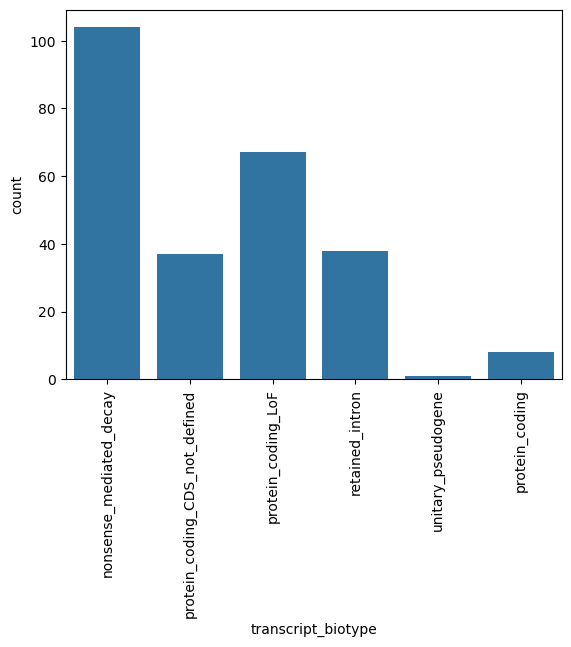

In [24]:
# get the biotype of the 89 genes missing IDs with transcript type
missingID_biotypes = get_biotypes_with_transcripts(
    exonBED[exonBED['geneID'].isna() == True][3].unique().tolist()
)
# plot those for summary
sns.countplot(
    data = missingID_biotypes,
    x = 'transcript_biotype',
    
)
plt.xticks(rotation = 90)

In [25]:
missingID_biotypes.head()

,symbol,ensembl_gene_id,gene_biotype,transcript_id,transcript_biotype,transcript_length,is_canonical,tsl,appris
0,ZFP91-CNTF,ENSG00000255073,protein_coding,ENST00000389919,nonsense_mediated_decay,2319,True,None,None
1,ZFP91-CNTF,ENSG00000255073,protein_coding,ENST00000422974,nonsense_mediated_decay,1788,False,None,None
2,MSH5-SAPCD1,ENSG00000255152,protein_coding,ENST00000493662,nonsense_mediated_decay,3991,True,None,None
3,MSH5-SAPCD1,ENSG00000255152,protein_coding,ENST00000498473,nonsense_mediated_decay,2216,False,None,None
4,MSH5-SAPCD1,ENSG00000255152,protein_coding,ENST00000491552,protein_coding_CDS_not_defined,706,False,None,None


In [26]:
# check the subset that are labeled protein_coding
missingID_biotypes[missingID_biotypes['transcript_biotype'] == 'protein_coding']

,symbol,ensembl_gene_id,gene_biotype,transcript_id,transcript_biotype,transcript_length,is_canonical,tsl,appris
48,NPHP3-ACAD11,ENSG00000274810,protein_coding,ENST00000632629,protein_coding,695,True,None,None
209,LRRC9,ENSG00000131951,protein_coding,ENST00000445360,protein_coding,4717,False,None,None
210,LRRC9,ENSG00000131951,protein_coding,ENST00000647410,protein_coding,4886,False,None,None
212,LRRC9,ENSG00000131951,protein_coding,ENST00000570145,protein_coding,8103,True,None,None
233,PKD1L2,ENSG00000166473,protein_coding,ENST00000531391,protein_coding,1488,False,None,None
234,PKD1L2,ENSG00000166473,protein_coding,ENST00000526632,protein_coding,2006,False,None,None
236,PKD1L2,ENSG00000166473,protein_coding,ENST00000527937,protein_coding,4165,False,None,None
237,PKD1L2,ENSG00000166473,protein_coding,ENST00000715690,protein_coding,3732,False,None,None


In [27]:
# check those IDs and see if they are uniquely protein_coding
# ENSG00000274810
display(missingID_biotypes[missingID_biotypes['ensembl_gene_id'] == 'ENSG00000274810'])
# check the transcript in gencode
!zcat {gencode_v44} | awk -F'\t' '$3=="exon" || $3=="gene"' | grep 'ENSG00000274810' | head -n 5
# | head -n 5
### NPHP3-ACAD11 is a readthrough gene, should not be considered per our rules ###
!zgrep 'ENST00000632629' {gencode_v44} # no output
# the transcript is not included in gencode basic as it has incomplete 5', 3' CDS, again should not be considered per our filters

,symbol,ensembl_gene_id,gene_biotype,transcript_id,transcript_biotype,transcript_length,is_canonical,tsl,appris
47,NPHP3-ACAD11,ENSG00000274810,protein_coding,ENST00000471702,nonsense_mediated_decay,7784,False,None,None
48,NPHP3-ACAD11,ENSG00000274810,protein_coding,ENST00000632629,protein_coding,695,True,None,None


chr3	HAVANA	gene	132558142	132722459	.	-	.	ID=ENSG00000274810.4;gene_id=ENSG00000274810.4;gene_type=protein_coding;gene_name=NPHP3-ACAD11;level=2;hgnc_id=HGNC:48351;tag=overlapping_locus,readthrough_gene;havana_gene=OTTHUMG00000187276.4
chr3	HAVANA	exon	132721963	132722459	.	-	.	ID=exon:ENST00000471702.2:1;Parent=ENST00000471702.2;gene_id=ENSG00000274810.4;transcript_id=ENST00000471702.2;gene_type=protein_coding;gene_name=NPHP3-ACAD11;transcript_type=nonsense_mediated_decay;transcript_name=NPHP3-ACAD11-201;exon_number=1;exon_id=ENSE00002208495.1;level=2;protein_id=ENSP00000419763.1;transcript_support_level=2;hgnc_id=HGNC:48351;tag=basic,appris_principal_2,readthrough_transcript;havana_gene=OTTHUMG00000187276.4;havana_transcript=OTTHUMT00000474684.2
chr3	HAVANA	exon	132719705	132719830	.	-	.	ID=exon:ENST00000471702.2:2;Parent=ENST00000471702.2;gene_id=ENSG00000274810.4;transcript_id=ENST00000471702.2;gene_type=protein_coding;gene_name=NPHP3-ACAD11;transcript_type=nonsense_mediated_decay

In [28]:
# ENSG00000131951
display(missingID_biotypes[missingID_biotypes['ensembl_gene_id'] == 'ENSG00000131951'])
!zcat {gencode_v44} | awk -F'\t' '$3=="exon" || $3=="gene"' | grep 'ENSG00000131951' | head -n 5
#| head -n 5
!zgrep 'ENST00000570145' {gencode_v44} # no output
# the canonical transcript is not included in gencode v44 basic

,symbol,ensembl_gene_id,gene_biotype,transcript_id,transcript_biotype,transcript_length,is_canonical,tsl,appris
208,LRRC9,ENSG00000131951,protein_coding,ENST00000254271,nonsense_mediated_decay,4915,False,None,None
209,LRRC9,ENSG00000131951,protein_coding,ENST00000445360,protein_coding,4717,False,None,None
210,LRRC9,ENSG00000131951,protein_coding,ENST00000647410,protein_coding,4886,False,None,None
211,LRRC9,ENSG00000131951,protein_coding,ENST00000454474,protein_coding_CDS_not_defined,880,False,None,None
212,LRRC9,ENSG00000131951,protein_coding,ENST00000570145,protein_coding,8103,True,None,None
213,LRRC9,ENSG00000131951,protein_coding,ENST00000562571,retained_intron,514,False,None,None
214,LRRC9,ENSG00000131951,protein_coding,ENST00000568404,nonsense_mediated_decay,799,False,None,None
215,LRRC9,ENSG00000131951,protein_coding,ENST00000644811,nonsense_mediated_decay,647,False,None,None


chr14	HAVANA	gene	59919713	60066817	.	+	.	ID=ENSG00000131951.12;gene_id=ENSG00000131951.12;gene_type=protein_coding;gene_name=LRRC9;level=2;hgnc_id=HGNC:19848;havana_gene=OTTHUMG00000028948.5
chr14	HAVANA	exon	59919713	59919883	.	+	.	ID=exon:ENST00000445360.5:1;Parent=ENST00000445360.5;gene_id=ENSG00000131951.12;transcript_id=ENST00000445360.5;gene_type=protein_coding;gene_name=LRRC9;transcript_type=protein_coding;transcript_name=LRRC9-202;exon_number=1;exon_id=ENSE00001382122.1;level=2;protein_id=ENSP00000454748.1;transcript_support_level=5;hgnc_id=HGNC:19848;tag=inferred_exon_combination,not_organism_supported,RNA_Seq_supported_partial,basic;havana_gene=OTTHUMG00000028948.5;havana_transcript=OTTHUMT00000072281.4
chr14	HAVANA	exon	59927911	59927991	.	+	.	ID=exon:ENST00000445360.5:2;Parent=ENST00000445360.5;gene_id=ENSG00000131951.12;transcript_id=ENST00000445360.5;gene_type=protein_coding;gene_name=LRRC9;transcript_type=protein_coding;transcript_name=LRRC9-202;exon_number=2;exon_id=EN

In [29]:
# ENSG00000166473
display(missingID_biotypes[missingID_biotypes['ensembl_gene_id'] == 'ENSG00000166473'])
!zcat {gencode_v44} | awk -F'\t' '$3=="exon" || $3=="gene"' | grep 'ENSG00000166473' | head -n 5
!zgrep 'ENST00000525539' {gencode_v44} | head -n 5
# canonical transcript is called as a LoF transcript, should not be considered

,symbol,ensembl_gene_id,gene_biotype,transcript_id,transcript_biotype,transcript_length,is_canonical,tsl,appris
226,PKD1L2,ENSG00000166473,protein_coding,ENST00000534447,retained_intron,5330,False,None,None
227,PKD1L2,ENSG00000166473,protein_coding,ENST00000534142,protein_coding_CDS_not_defined,2012,False,None,None
228,PKD1L2,ENSG00000166473,protein_coding,ENST00000533478,protein_coding_LoF,5669,False,None,None
229,PKD1L2,ENSG00000166473,protein_coding,ENST00000525539,protein_coding_LoF,7379,True,None,None
230,PKD1L2,ENSG00000166473,protein_coding,ENST00000530363,retained_intron,1608,False,None,None
231,PKD1L2,ENSG00000166473,protein_coding,ENST00000299598,retained_intron,5818,False,None,None
232,PKD1L2,ENSG00000166473,protein_coding,ENST00000529079,retained_intron,574,False,None,None
233,PKD1L2,ENSG00000166473,protein_coding,ENST00000531391,protein_coding,1488,False,None,None
234,PKD1L2,ENSG00000166473,protein_coding,ENST00000526632,protein_coding,2006,False,None,None
235,PKD1L2,ENSG00000166473,protein_coding,ENST00000710634,nonsense_mediated_decay,1517,False,None,None


chr16	HAVANA	gene	81100875	81220370	.	-	.	ID=ENSG00000166473.19;gene_id=ENSG00000166473.19;gene_type=protein_coding;gene_name=PKD1L2;level=1;hgnc_id=HGNC:21715;tag=ncRNA_host;havana_gene=OTTHUMG00000166126.5
chr16	HAVANA	exon	81181151	81181324	.	-	.	ID=exon:ENST00000533478.5:1;Parent=ENST00000533478.5;gene_id=ENSG00000166473.19;transcript_id=ENST00000533478.5;gene_type=protein_coding;gene_name=PKD1L2;transcript_type=protein_coding_LoF;transcript_name=PKD1L2-209;exon_number=1;exon_id=ENSE00002271634.1;level=2;protein_id=ENSP00000434644.1;transcript_support_level=1;hgnc_id=HGNC:21715;tag=basic;havana_gene=OTTHUMG00000166126.5;havana_transcript=OTTHUMT00000387970.3
chr16	HAVANA	exon	81179645	81179786	.	-	.	ID=exon:ENST00000533478.5:2;Parent=ENST00000533478.5;gene_id=ENSG00000166473.19;transcript_id=ENST00000533478.5;gene_type=protein_coding;gene_name=PKD1L2;transcript_type=protein_coding_LoF;transcript_name=PKD1L2-209;exon_number=2;exon_id=ENSE00003472218.1;level=2;protein_id=ENSP00000434

In [30]:
# okay so the three unique protein_coding tagged genes are not to be worried about, they do not pass our filtering criteria
# use the pulled ensembl gene names/transcript ids for matching
# there are 3 gene names that didn't return ensembl genes print them here:
print(set(exonBED[exonBED['geneID'].isna() == True][3].unique().tolist()) - set(missingID_biotypes['symbol'].unique()))
# OR2B8P is a LoF gene
# OR8G3P is a LoF gene
# OR9H1P is a LoF gene
# manually build that dictionary using ensembl web query
manualGeneID_dict = {
    'OR2B8P' : 'ENSG00000182477',
    'OR8G3P' : 'ENSG00000255425',
    'OR9H1P' : 'ENSG00000228336'
}
manualTranscriptID_dict = {
    'OR2B8P' : 'ENST00000432841',
    'OR8G3P' : 'ENST00000641848',
    'OR9H1P' : 'ENST00000446393'
}
# make a dictionary of the other 86 genes for filtering/identifying them in the VEP output
# gene id
ensemblGeneID_dict = dict(zip(
    missingID_biotypes['symbol'],
    missingID_biotypes['ensembl_gene_id']
))
ensemblGeneID_dict.update(manualGeneID_dict)
# transcript id
ensemblTranscriptID_dict = dict(zip(
    missingID_biotypes['symbol'],
    missingID_biotypes['transcript_id']
))
ensemblTranscriptID_dict.update(manualTranscriptID_dict)
# split the bed file with annotations into those that already have matches from our BED file and those we need to add the returned annotations from ensembl
easyMatchedBED = exonBED[exonBED['geneID'].isna() == False].copy()
missingMatchBED = exonBED[exonBED['geneID'].isna() == True].copy()
# add the gene ID and transcript ID to the ones that were missing
missingMatchBED.loc[:, 'geneID'] = [ensemblGeneID_dict.get(i) for i in missingMatchBED[3]]
missingMatchBED.loc[:, 'transcriptID'] = [ensemblTranscriptID_dict.get(i) for i in missingMatchBED[3]]
print('### Checking previously missing BED file genes for geneID and transcriptID ###')
print(missingMatchBED['geneID'].isna().value_counts())
print(missingMatchBED['transcriptID'].isna().value_counts())
# corrected! reconcatenate
fullyMatchedBED = pd.concat([easyMatchedBED, missingMatchBED])
print('### Checking final BED file for geneID and transcriptID ###')
print(fullyMatchedBED['geneID'].isna().value_counts())
print(fullyMatchedBED['transcriptID'].isna().value_counts())

{'OR9H1P', 'OR2B8P', 'OR8G3P'}


### Checking previously missing BED file genes for geneID and transcriptID ###
geneID
False    1246
Name: count, dtype: int64
transcriptID
False    1246
Name: count, dtype: int64
### Checking final BED file for geneID and transcriptID ###
geneID
False    674268
Name: count, dtype: int64
transcriptID
False    674268
Name: count, dtype: int64


In [31]:
newBED_df.head()

,0,1,2,3,4,5,6,7,8,9
0,chr1,65418,65433,OR4F5,0,+,ENSG00000186092.7,ENST00000641515.2,ENSE00003812156.1,1
1,chr1,65519,65573,OR4F5,0,+,ENSG00000186092.7,ENST00000641515.2,ENSE00003813641.1,2
2,chr1,69036,71585,OR4F5,0,+,ENSG00000186092.7,ENST00000641515.2,ENSE00003813949.1,3
3,chr1,450739,451678,OR4F29,0,-,ENSG00000284733.2,ENST00000426406.4,ENSE00003989331.1,1
4,chr1,685715,686654,OR4F16,0,-,ENSG00000284662.2,ENST00000332831.5,ENSE00004001351.2,1


In [32]:
newBedWithReg.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,COSV59703864,chr1:926008,A,ENSG00000187634,ENST00000342066,Transcript,missense_variant,-,-,ENST00000618181,-,MODERATE,-
1,COSV59703864,chr1:926008,A,ENSG00000187634,ENST00000437963,Transcript,missense_variant,-,-,ENST00000618181,-,MODERATE,cds_end_NF
2,COSV59703864,chr1:926008,A,ENSG00000187634,ENST00000616016,Transcript,missense_variant,-,YES,ENST00000618181,-,MODERATE,-
3,COSV59703864,chr1:926008,A,ENSG00000187634,ENST00000616125,Transcript,missense_variant,-,-,ENST00000618181,-,MODERATE,cds_start_NF
4,COSV59703864,chr1:926008,A,ENSG00000187634,ENST00000617307,Transcript,missense_variant,-,-,ENST00000618181,-,MODERATE,cds_start_NF


In [33]:
# okay let's see how how many features intersect with our exon calls
# filter with the transcript ids
# pad + reg
paddedWithRegOurExons = paddedWithReg[paddedWithReg[4].isin(list(fullyMatchedBED['transcriptID'].unique()))]
# no pad + reg
noPadWithRegOurExons = noPadWithReg[noPadWithReg[4].isin(list(fullyMatchedBED['transcriptID'].unique()))]
# pad only
padOnlyWithRegOurExons = padOnlyWithReg[padOnlyWithReg[4].isin(list(fullyMatchedBED['transcriptID'].unique()))]
# new BED
noPadWithRegNewExons = newBedWithReg[newBedWithReg[4].isin([i.split('.')[0] for i in newBED_df[7].unique()])]

In [35]:
# group the calls by variant id
# pad + reg
# paddedWithRegOurExons_grouped = paddedWithRegOurExons.groupby(0).agg({
#     1 : 'first', # chromosome + position
#     2 : 'first', # alt variant
#     3 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # stable id of gene
#     4 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # transcript id
#     5 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # feature_type
#     6 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # consequence
#     8 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # canonical
#     9 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # nearest transcript
#     11 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # predicted impact
# }).reset_index()
# no pad + reg
noPadWithRegOurExons_grouped = noPadWithRegOurExons.groupby(0).agg({
    1 : 'first', # chromosome + position
    2 : 'first', # alt variant
    3 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # stable id of gene
    4 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # transcript id
    5 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # feature_type
    6 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # consequence
    8 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # canonical
    9 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # nearest transcript
    11 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # predicted impact
}).reset_index()
# pad only + reg
# padOnlyWithReg_grouped = padOnlyWithRegOurExons.groupby(0).agg({
#     1 : 'first', # chromosome + position
#     2 : 'first', # alt variant
#     3 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # stable id of gene
#     4 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # transcript id
#     5 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # feature_type
#     6 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # consequence
#     8 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # canonical
#     9 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # nearest transcript
#     11 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # predicted impact
# }).reset_index()
# updated bed + reg
noPadWithRegNewExons_grouped = noPadWithRegNewExons.groupby(0).agg({
    1 : 'first', # chromosome + position
    2 : 'first', # alt variant
    3 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # stable id of gene
    4 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # transcript id
    5 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # feature_type
    6 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # consequence
    8 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # canonical
    9 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # nearest transcript
    11 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # predicted impact
}).reset_index()

In [36]:
# check all variant IDs are present in VEP
# pad + reg
# paddedWithRegMissingVars = list(set(padIntersect.to_dataframe()['name']) - set(paddedWithRegOurExons_grouped[0].unique()))
# print(f'there are {len(paddedWithRegMissingVars)} variants that do not have a VEP annotation from the padded exon intersection')
# no pad + reg
noPadWithRegMissingVars = list(set(noPadIntersect.to_dataframe()['name']) - set(noPadWithRegOurExons_grouped[0].unique()))
print(f'there are {len(noPadWithRegMissingVars)} variants that do not have a VEP annotation from no pad exon intersection')
# pad only + reg
# padOnlyWithRegMissingVars = list(set(padOnlyIntersect.to_dataframe()['name']) - set(padOnlyWithReg_grouped[0].unique()))
# print(f'there are {len(padOnlyWithRegMissingVars)} variants that do not have a VEP annotation from the pad only intersection')
# new bed + reg
noPadNewBedWithRegMissingVars = list(set(newBedIntersect.to_dataframe()['name']) - set(noPadWithRegNewExons_grouped[0].unique()))
print(f'there are {len(noPadNewBedWithRegMissingVars)} variants that do not have a VEP annotation from the updated, exon only, bed file')

there are 2913 variants that do not have a VEP annotation from no pad exon intersection
there are 137 variants that do not have a VEP annotation from the updated, exon only, bed file


In [40]:
noPadWithRegNewExons_grouped.head()

,0,1,2,3,4,5,6,8,9,11
0,COSV100000001,chr11:5679890,C,ENSG00000132256,ENST00000380034,Transcript,synonymous_variant,YES,ENST00000438025,LOW
1,COSV100000008,chr12:121856399,A,ENSG00000158104,ENST00000289004,Transcript,synonymous_variant,YES,ENST00000289004,LOW
2,COSV100000014,chr12:121846915,A,ENSG00000158104,ENST00000289004,Transcript,missense_variant,YES,ENST00000289004,MODERATE
3,COSV100000091,chr6:154089954,C,ENSG00000112038,ENST00000330432,Transcript,missense_variant,YES,ENST00000522555,MODERATE
4,COSV100000187,chr12:121854786,A,ENSG00000158104,ENST00000289004,Transcript,missense_variant,YES,ENST00000289004,MODERATE


In [41]:
# okay let's assign coding to these groupby
def has_exonic_coding(consequences):
    """Check if any consequence in the comma-separated string is exonic coding."""
    EXONIC_CODING = [
        "transcript_ablation", "stop_gained", "frameshift_variant",
        "stop_lost", "start_lost", "inframe_insertion", "inframe_deletion",
        "missense_variant", "protein_altering_variant",
        "incomplete_terminal_codon_variant", "start_retained_variant",
        "stop_retained_variant", "synonymous_variant", "coding_sequence_variant",
    ]
    return any(c.strip() in EXONIC_CODING for c in str(consequences).split(","))

In [43]:
# add exon binary column
# pad + reg
# paddedWithRegOurExons_grouped['is_exonic_coding'] = paddedWithRegOurExons_grouped[6].apply(has_exonic_coding).astype(int)
# no pad + reg
noPadWithRegOurExons_grouped['is_exonic_coding'] = noPadWithRegOurExons_grouped[6].apply(has_exonic_coding).astype(int)
# pad only
# padOnlyWithReg_grouped['is_exonic_coding'] = padOnlyWithReg_grouped[6].apply(has_exonic_coding).astype(int)
# new bed + reg
noPadWithRegNewExons_grouped['is_exonic_coding'] = noPadWithRegNewExons_grouped[6].apply(has_exonic_coding).astype(int)

In [55]:
noPadWithRegOurExons_grouped['is_exonic_coding'].sum()

np.int64(445149)

In [56]:
noPadWithRegNewExons_grouped['is_exonic_coding'].sum()

np.int64(445220)

In [47]:
# add most severe consequence
VEP_SEVERITY = [
    "transcript_ablation",
    "splice_acceptor_variant",
    "splice_donor_variant",
    "stop_gained",
    "frameshift_variant",
    "stop_lost",
    "start_lost",
    "transcript_amplification",
    "inframe_insertion",
    "inframe_deletion",
    "missense_variant",
    "protein_altering_variant",
    "splice_donor_5th_base_variant",
    "splice_region_variant",
    "splice_donor_region_variant",
    "splice_polypyrimidine_tract_variant",
    "incomplete_terminal_codon_variant",
    "start_retained_variant",
    "stop_retained_variant",
    "synonymous_variant",
    "coding_sequence_variant",
    "mature_miRNA_variant",
    "5_prime_UTR_variant",
    "3_prime_UTR_variant",
    "non_coding_transcript_exon_variant",
    "intron_variant",
    "NMD_transcript_variant",
    "non_coding_transcript_variant",
    "upstream_gene_variant",
    "downstream_gene_variant",
    "TFBS_ablation",
    "TFBS_amplification",
    "TF_binding_site_variant",
    "regulatory_region_ablation",
    "regulatory_region_amplification",
    "feature_elongation",
    "regulatory_region_variant",
    "feature_truncation",
    "intergenic_variant",
]

# Lower index = more severe
SEVERITY_RANK = {term: i for i, term in enumerate(VEP_SEVERITY)}

def most_severe(consequences):
    """Return the most severe consequence from a comma-separated string."""
    terms = [c.strip() for c in str(consequences).split(",")]
    ranked = sorted(terms, key=lambda t: SEVERITY_RANK.get(t, 999))
    return ranked[0]

In [49]:
# add most severe annotation
# pad + reg
# paddedWithRegOurExons_grouped['most_severe'] = paddedWithRegOurExons_grouped[6].apply(most_severe)
# no pad + reg
noPadWithRegOurExons_grouped['most_severe'] = noPadWithRegOurExons_grouped[6].apply(most_severe)
# pad only
# padOnlyWithReg_grouped['most_severe'] = padOnlyWithReg_grouped[6].apply(most_severe)
# new bed + reg
noPadWithRegNewExons_grouped['most_severe'] = noPadWithRegNewExons_grouped[6].apply(most_severe)

In [50]:
# add impact
IMPACT_MAP = {
    "transcript_ablation": "HIGH",
    "splice_acceptor_variant": "HIGH",
    "splice_donor_variant": "HIGH",
    "stop_gained": "HIGH",
    "frameshift_variant": "HIGH",
    "stop_lost": "HIGH",
    "start_lost": "HIGH",
    "transcript_amplification": "HIGH",
    "inframe_insertion": "MODERATE",
    "inframe_deletion": "MODERATE",
    "missense_variant": "MODERATE",
    "protein_altering_variant": "MODERATE",
    "splice_donor_5th_base_variant": "LOW",
    "splice_region_variant": "LOW",
    "splice_donor_region_variant": "LOW",
    "splice_polypyrimidine_tract_variant": "LOW",
    "incomplete_terminal_codon_variant": "LOW",
    "start_retained_variant": "LOW",
    "stop_retained_variant": "LOW",
    "synonymous_variant": "LOW",
    "coding_sequence_variant": "LOW",
    "mature_miRNA_variant": "MODIFIER",
    "5_prime_UTR_variant": "MODIFIER",
    "3_prime_UTR_variant": "MODIFIER",
    "non_coding_transcript_exon_variant": "MODIFIER",
    "intron_variant": "MODIFIER",
    "NMD_transcript_variant": "MODIFIER",
    "non_coding_transcript_variant": "MODIFIER",
    "upstream_gene_variant": "MODIFIER",
    "downstream_gene_variant": "MODIFIER",
    "TFBS_ablation": "MODIFIER",
    "TFBS_amplification": "MODIFIER",
    "TF_binding_site_variant": "MODIFIER",
    "regulatory_region_ablation": "MODERATE",
    "regulatory_region_amplification": "MODIFIER",
    "feature_elongation": "MODIFIER",
    "regulatory_region_variant": "MODIFIER",
    "feature_truncation": "MODIFIER",
    "intergenic_variant": "MODIFIER",
}
# pad + reg
# paddedWithRegOurExons_grouped['most_severe_impact'] = paddedWithRegOurExons_grouped['most_severe'].map(IMPACT_MAP)
# no pad + reg
noPadWithRegOurExons_grouped['most_severe_impact'] = noPadWithRegOurExons_grouped['most_severe'].map(IMPACT_MAP)
# pad only
# padOnlyWithReg_grouped['most_severe_impact'] = padOnlyWithReg_grouped['most_severe'].map(IMPACT_MAP)
# new bed + reg
noPadWithRegNewExons_grouped['most_severe_impact'] = noPadWithRegNewExons_grouped['most_severe'].map(IMPACT_MAP)

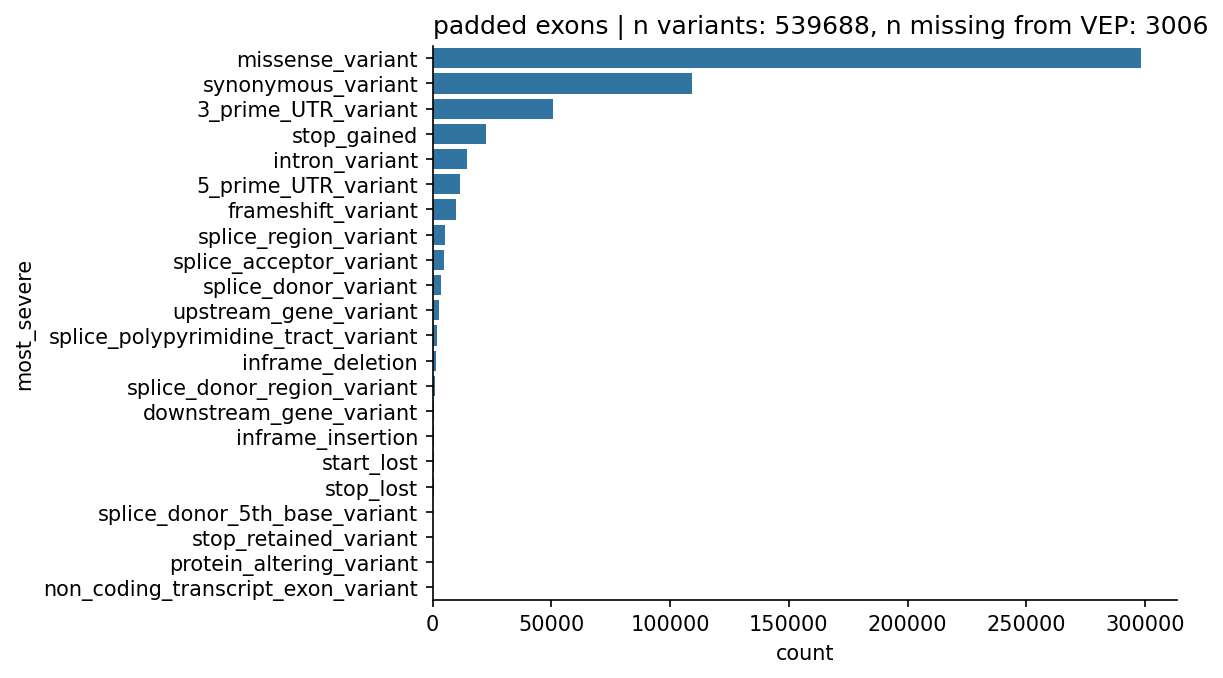

In [105]:
# plot the count of the most severe annotation for each
# pad + reg
plt.figure(dpi=150)
sns.countplot(
    paddedWithRegOurExons_grouped['most_severe'],
    order = paddedWithRegOurExons_grouped['most_severe'].value_counts().index
)
plt.title(f'padded exons | n variants: {len(paddedWithRegOurExons_grouped)}, n missing from VEP: {len(paddedWithRegMissingVars)}', loc='left')
sns.despine()

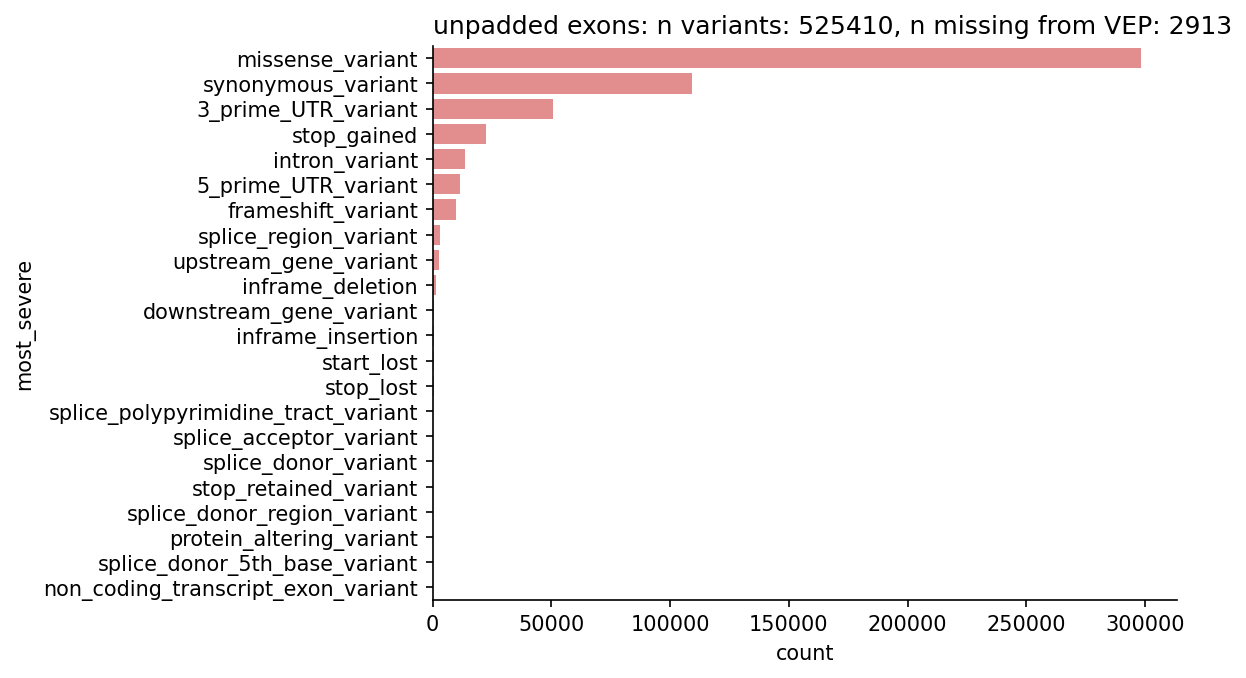

In [103]:
# no pad + reg
plt.figure(dpi=150)
sns.countplot(
    noPadWithRegOurExons_grouped['most_severe'],
    order = noPadWithRegOurExons_grouped['most_severe'].value_counts().index,
    color='lightcoral'
)
plt.title(f'unpadded exons | n variants: {len(noPadWithRegOurExons_grouped)}, n missing from VEP: {len(noPadWithRegMissingVars)}', loc='left')
sns.despine()

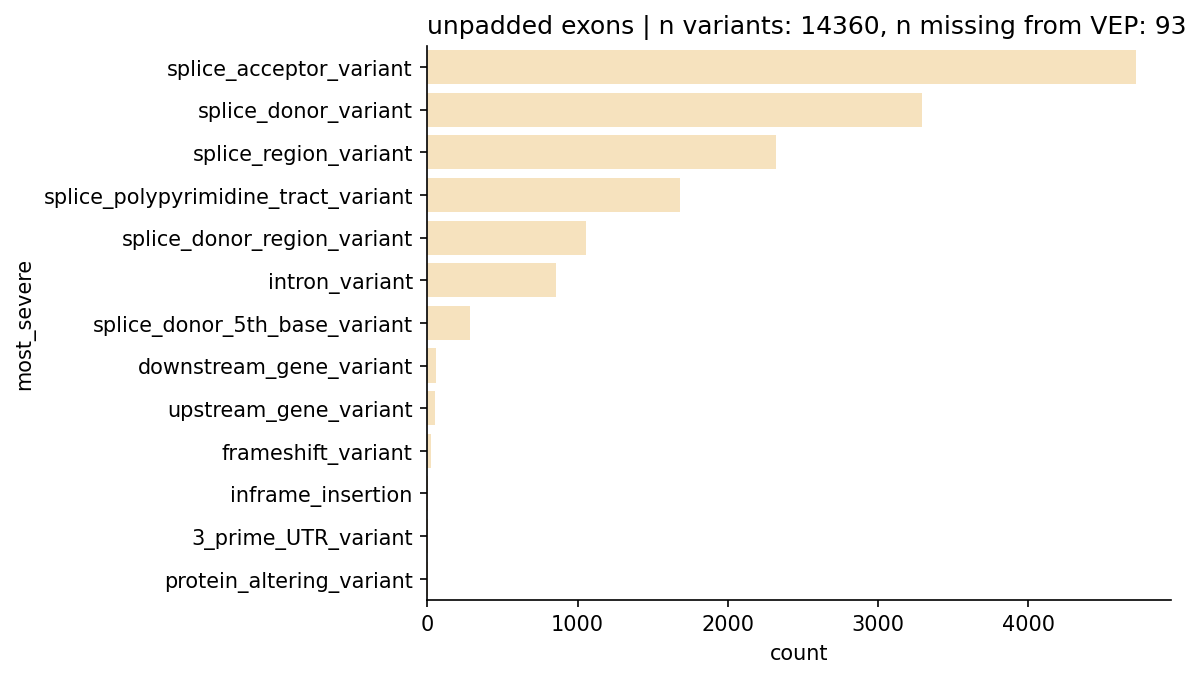

In [106]:
# pad only
plt.figure(dpi=150)
sns.countplot(
    padOnlyWithReg_grouped['most_severe'],
    order = padOnlyWithReg_grouped['most_severe'].value_counts().index,
    color='moccasin'
)
plt.title(f'unpadded exons | n variants: {len(padOnlyWithReg_grouped)}, n missing from VEP: {len(padOnlyWithRegMissingVars)}', loc='left')
sns.despine()

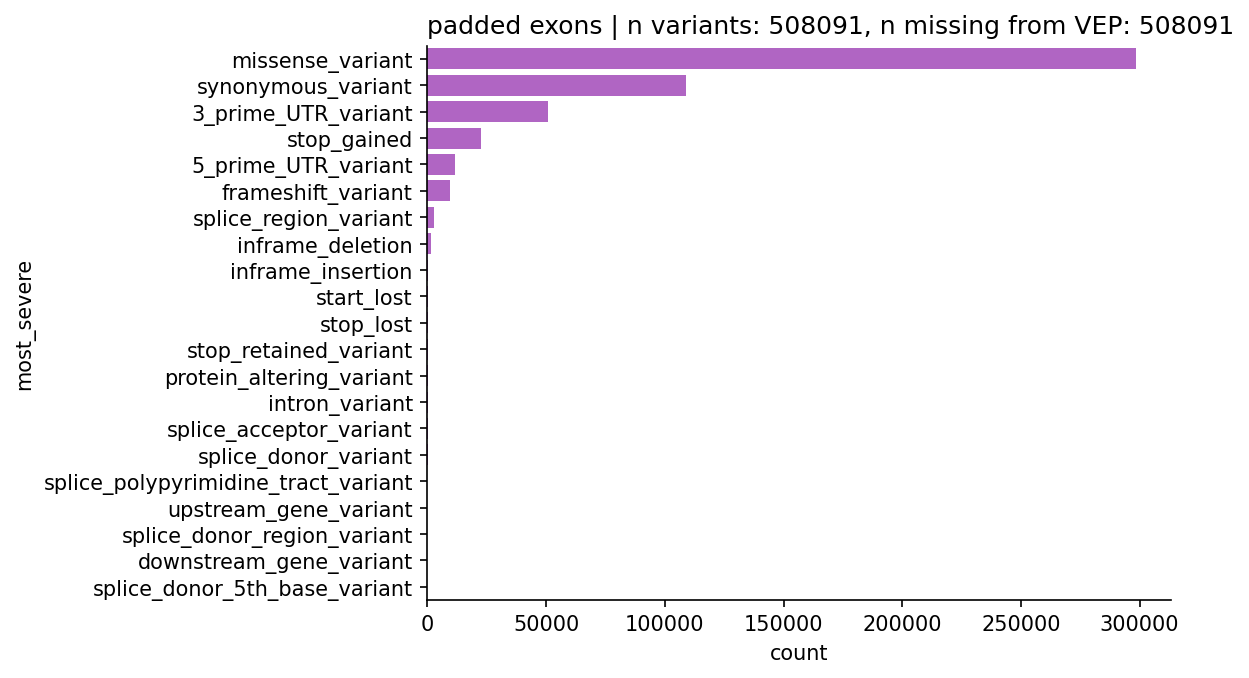

In [51]:
# plot the count of the most severe annotation for each
# pad + reg
plt.figure(dpi=150)
sns.countplot(
    noPadWithRegNewExons_grouped['most_severe'],
    order = noPadWithRegNewExons_grouped['most_severe'].value_counts().index,
    color='mediumorchid'
)
plt.title(f'padded exons | n variants: {len(noPadWithRegNewExons_grouped)}, n missing from VEP: {len(noPadWithRegNewExons_grouped)}', loc='left')
sns.despine()

In [53]:
Counter(noPadWithRegNewExons_grouped['most_severe'])

Counter({'missense_variant': 298471,
         'synonymous_variant': 109047,
         '3_prime_UTR_variant': 50764,
         'stop_gained': 22482,
         '5_prime_UTR_variant': 11669,
         'frameshift_variant': 9703,
         'splice_region_variant': 2764,
         'inframe_deletion': 1467,
         'inframe_insertion': 451,
         'start_lost': 441,
         'stop_lost': 377,
         'stop_retained_variant': 137,
         'protein_altering_variant': 84,
         'intron_variant': 66,
         'splice_acceptor_variant': 44,
         'splice_donor_variant': 43,
         'splice_polypyrimidine_tract_variant': 33,
         'upstream_gene_variant': 33,
         'splice_donor_region_variant': 7,
         'downstream_gene_variant': 6,
         'splice_donor_5th_base_variant': 2})

In [63]:
### okay those exons seem right. let's break this down further at the cosmic level for now ###
# make a dictionary of cosmicID : most severe consequence pairs for annotating cosmic data
vepCons_dict = dict(zip(
    noPadWithRegNewExons_grouped[0],
    noPadWithRegNewExons_grouped['most_severe']
))
# annotate the cosmic tsv - for the 137 missing annotations add 'NoVEP' for checking
allCosmic.loc['vep_most_severe'] = 

In [ ]:
### SCRATCH ###

In [62]:
allCosmic.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_pro_seqlet,250_pro_seqlet,k562_dELS_seqlet_tf_fam,hepg2_dELS_seqlet_tf_fam,sknsh_dELS_seqlet_tf_fam,k562_dELS_seqlet_enh_ID,hepg2_dELS_seqlet_enh_ID,sknsh_dELS_seqlet_enh_ID,primary_histology,all_histology
0,chr5,12057,COSV104949790,C,G,0.290299,0.484281,0.193983,0.236332,0.486731,...,0,0,0,CREB/ATF/3,0,0,EH38E3621011,0,carcinoma,carcinoma
1,chr5,12314,COSV106176984,C,T,3.124992,2.110848,-1.014144,2.444942,1.962961,...,0,0,0,0,0,0,0,0,undifferentiated-unclassified_sarcoma,undifferentiated-unclassified_sarcoma
2,chr5,13609,COSV64422606,C,T,0.165250,0.171957,0.006708,0.221217,0.226838,...,0,0,0,0,0,0,0,0,carcinoma,carcinoma
3,chr5,14173,COSV61294243,A,C,-0.059066,-0.023485,0.035582,-0.192251,-0.133702,...,0,0,0,0,0,0,0,0,carcinoma,carcinoma
4,chr5,14196,COSV106241292,G,C,-0.066014,-0.059922,0.006092,-0.220630,-0.198749,...,0,0,0,0,0,0,0,0,undifferentiated-unclassified_sarcoma,undifferentiated-unclassified_sarcoma


In [57]:
# grep some SAMD11 for example
# print all exons in previous BED file
!grep 'SAMD11' ../raw_data/gencode.v44.protein.coding.exons.autosomes.v2.bed

chr1	923922	924948	SAMD11	0	+
chr1	925921	926013	SAMD11	0	+
chr1	930154	930336	SAMD11	0	+
chr1	931038	931089	SAMD11	0	+
chr1	935771	935896	SAMD11	0	+
chr1	939039	939129	SAMD11	0	+
chr1	939274	939412	SAMD11	0	+
chr1	941143	941306	SAMD11	0	+
chr1	942135	942251	SAMD11	0	+
chr1	942409	942488	SAMD11	0	+
chr1	942558	943058	SAMD11	0	+
chr1	943252	943377	SAMD11	0	+
chr1	943697	943808	SAMD11	0	+
chr1	943907	944574	SAMD11	0	+
chr1	923922	924948	SAMD11	0	+
chr1	925921	926013	SAMD11	0	+
chr1	930154	930336	SAMD11	0	+
chr1	931038	931089	SAMD11	0	+
chr1	935771	935896	SAMD11	0	+
chr1	939039	939129	SAMD11	0	+
chr1	939271	939412	SAMD11	0	+
chr1	941143	941306	SAMD11	0	+
chr1	942135	942251	SAMD11	0	+
chr1	942409	942488	SAMD11	0	+
chr1	942558	943058	SAMD11	0	+
chr1	943252	943377	SAMD11	0	+
chr1	943697	943808	SAMD11	0	+
chr1	943907	944574	SAMD11	0	+
chr1	925730	925800	SAMD11	0	+
chr1	925921	926013	SAMD11	0	+
chr1	930154	930336	SAMD11	0	+
chr1	931038	931089	SAMD11	0	+
chr1	935771	935896	SAMD11	0	+
chr1	93903

In [61]:
# check those IDs and see if they are uniquely protein_coding
# SAMD11
# check the transcript in gencode
!zcat {gencode_v44} | awk -F'\t' '$3=="exon" || $3=="gene"' | grep 'ENSG00000187634'
#!zgrep 'ENST00000616016' {gencode_v44}

chr1	HAVANA	gene	923923	944575	.	+	.	ID=ENSG00000187634.13;gene_id=ENSG00000187634.13;gene_type=protein_coding;gene_name=SAMD11;level=2;hgnc_id=HGNC:28706;havana_gene=OTTHUMG00000040719.11
chr1	HAVANA	exon	923923	924948	.	+	.	ID=exon:ENST00000616016.5:1;Parent=ENST00000616016.5;gene_id=ENSG00000187634.13;transcript_id=ENST00000616016.5;gene_type=protein_coding;gene_name=SAMD11;transcript_type=protein_coding;transcript_name=SAMD11-209;exon_number=1;exon_id=ENSE00001637883.3;level=2;protein_id=ENSP00000478421.2;transcript_support_level=5;hgnc_id=HGNC:28706;tag=CAGE_supported_TSS,RNA_Seq_supported_partial,basic,Ensembl_canonical,MANE_Select,appris_alternative_2,CCDS;ccdsid=CCDS90834.1;havana_gene=OTTHUMG00000040719.11;havana_transcript=OTTHUMT00000316521.3
chr1	HAVANA	exon	925922	926013	.	+	.	ID=exon:ENST00000616016.5:2;Parent=ENST00000616016.5;gene_id=ENSG00000187634.13;transcript_id=ENST00000616016.5;gene_type=protein_coding;gene_name=SAMD11;transcript_type=protein_coding;transcript_nam

In [58]:
!grep 'SAMD11' ../raw_data/gencode.v44.protein.coding.exons.autosomes.canonical.annotated.bed

chr1	923922	924948	SAMD11	0	+	ENSG00000187634.13	ENST00000616016.5	ENSE00001637883.3	1
chr1	925921	926013	SAMD11	0	+	ENSG00000187634.13	ENST00000616016.5	ENSE00003794726.1	2
chr1	930154	930336	SAMD11	0	+	ENSG00000187634.13	ENST00000616016.5	ENSE00003915575.1	3
chr1	931038	931089	SAMD11	0	+	ENSG00000187634.13	ENST00000616016.5	ENSE00003911839.1	4
chr1	935771	935896	SAMD11	0	+	ENSG00000187634.13	ENST00000616016.5	ENSE00003911340.1	5
chr1	939039	939129	SAMD11	0	+	ENSG00000187634.13	ENST00000616016.5	ENSE00003912201.1	6
chr1	939274	939412	SAMD11	0	+	ENSG00000187634.13	ENST00000616016.5	ENSE00001708361.1	7
chr1	941143	941306	SAMD11	0	+	ENSG00000187634.13	ENST00000616016.5	ENSE00003477353.1	8
chr1	942135	942251	SAMD11	0	+	ENSG00000187634.13	ENST00000616016.5	ENSE00003913392.1	9
chr1	942409	942488	SAMD11	0	+	ENSG00000187634.13	ENST00000616016.5	ENSE00003675531.1	10
chr1	942558	943058	SAMD11	0	+	ENSG00000187634.13	ENST00000616016.5	ENSE00002728091.1	11
chr1	943252	943377	SAMD11	0	+	ENSG0000018

In [124]:
# subset the cosmic variants for the ones that aren't annotated as coding by VEP
# pad + reg
paddedNonCodingFromVEP = paddedWithRegOurExons_grouped[paddedWithRegOurExons_grouped['is_exonic_coding'] == 0][0].tolist()
# no pad + reg
noPadNonCodingFromVEP = noPadWithRegOurExons_grouped[noPadWithRegOurExons_grouped['is_exonic_coding'] == 0][0].tolist()
# filter the full cosmic bed file for those variants
# pad + reg
paddedVEPnoncoding_cosmic_bed = pybedtools.BedTool.from_dataframe(
    cosmic_bed.to_dataframe()[cosmic_bed.to_dataframe()['name'].isin(paddedNonCodingFromVEP)]
)
# no pad
noPadVEPnoncoding_cosmic_bed = pybedtools.BedTool.from_dataframe(
    cosmic_bed.to_dataframe()[cosmic_bed.to_dataframe()['name'].isin(noPadNonCodingFromVEP)]
)

In [147]:
# intersect the 'non-coding' variants with our exon bed file to see what they're hitting
paddedVEPnoncodingExons = exonsWithPad_proteinCoding.intersect(paddedVEPnoncoding_cosmic_bed, wa=True, wb=True)
noPadVEPnoncodingExons = exonsNoPad_proteinCoding.intersect(noPadVEPnoncoding_cosmic_bed, wa=True, wb=True)

In [146]:
paddedVEPnoncodingExons.head()

chr1	943887	944580	SAMD11	0	+	chr1	944237	944238	COSV100497961
 chr1	943887	944580	SAMD11	0	+	chr1	944413	944419	COSV58987552
 chr1	943887	944580	SAMD11	0	+	chr1	944237	944238	COSV100497961
 chr1	943887	944580	SAMD11	0	+	chr1	944413	944419	COSV58987552
 chr1	939254	939466	SAMD11	0	+	chr1	939436	939436	COSV58986063
 chr1	943887	944580	SAMD11	0	+	chr1	944237	944238	COSV100497961
 chr1	943887	944580	SAMD11	0	+	chr1	944413	944419	COSV58987552
 chr1	956088	956235	NOC2L	0	-	chr1	956091	956092	COSV104642996
 chr1	944196	944820	NOC2L	0	-	chr1	944237	944238	COSV100497961
 chr1	944196	944820	NOC2L	0	-	chr1	944413	944419	COSV58987552
 

In [151]:
noPadVEPnoncodingExons.head(20)

chr1	943907	944574	SAMD11	0	+	chr1	944237	944238	COSV100497961
 chr1	943907	944574	SAMD11	0	+	chr1	944413	944419	COSV58987552
 chr1	943907	944574	SAMD11	0	+	chr1	944237	944238	COSV100497961
 chr1	943907	944574	SAMD11	0	+	chr1	944413	944419	COSV58987552
 chr1	939274	939460	SAMD11	0	+	chr1	939436	939436	COSV58986063
 chr1	943907	944574	SAMD11	0	+	chr1	944237	944238	COSV100497961
 chr1	943907	944574	SAMD11	0	+	chr1	944413	944419	COSV58987552
 chr1	944202	944800	NOC2L	0	-	chr1	944237	944238	COSV100497961
 chr1	944202	944800	NOC2L	0	-	chr1	944413	944419	COSV58987552
 chr1	964962	965719	KLHL17	0	+	chr1	965239	965240	COSV100647599
 chr1	974441	975865	PLEKHN1	0	+	chr1	974950	974951	COSV100378978
 chr1	974441	975865	PLEKHN1	0	+	chr1	975279	975280	COSV100379244
 chr1	974441	975008	PLEKHN1	0	+	chr1	974950	974951	COSV100378978
 chr1	970685	971006	PLEKHN1	0	+	chr1	970787	970788	COSV104656590
 chr1	970685	971006	PLEKHN1	0	+	chr1	970828	970829	COSV58021772
 chr1	974441	975008	PLEKHN1	0	+	chr1	974950	

In [153]:
exonsNoPad_proteinCoding.to_dataframe()[exonsNoPad_proteinCoding.to_dataframe()['name'] == 'PERM1']

,chrom,start,end,name,score,strand
124,chr1,982064,982093,PERM1,0,-
125,chr1,978880,981173,PERM1,0,-
126,chr1,976498,976624,PERM1,0,-
127,chr1,975197,976269,PERM1,0,-
128,chr1,982064,982093,PERM1,0,-
129,chr1,981136,981173,PERM1,0,-
130,chr1,978880,980657,PERM1,0,-
131,chr1,976498,976624,PERM1,0,-
132,chr1,975203,976269,PERM1,0,-
133,chr1,982064,982117,PERM1,0,-


In [160]:
exonsNoPad_proteinCoding.to_dataframe()[exonsNoPad_proteinCoding.to_dataframe()['name'] == 'PLEKHN1'].sort_values(by='start')

,chrom,start,end,name,score,strand
78,chr1,966481,966614,PLEKHN1,0,+
94,chr1,966501,966614,PLEKHN1,0,+
109,chr1,966501,966614,PLEKHN1,0,+
79,chr1,966703,966803,PLEKHN1,0,+
95,chr1,966703,966803,PLEKHN1,0,+
110,chr1,966703,966803,PLEKHN1,0,+
80,chr1,970276,970423,PLEKHN1,0,+
96,chr1,970276,970423,PLEKHN1,0,+
111,chr1,970276,970423,PLEKHN1,0,+
112,chr1,970520,970601,PLEKHN1,0,+


In [158]:
fullyMatchedBED[fullyMatchedBED[3] == 'PLEKHN1'].drop_duplicates().sort_values(by=1, ascending = True)

,0,1,2,3,4,5,geneID,transcriptID
78,chr1,966481,966620,PLEKHN1,0,+,ENSG00000187583,ENST00000379410
94,chr1,966501,966620,PLEKHN1,0,+,ENSG00000187583,ENST00000379410
79,chr1,966683,966809,PLEKHN1,0,+,ENSG00000187583,ENST00000379410
80,chr1,970256,970429,PLEKHN1,0,+,ENSG00000187583,ENST00000379410
81,chr1,970500,970607,PLEKHN1,0,+,ENSG00000187583,ENST00000379410
82,chr1,970665,970764,PLEKHN1,0,+,ENSG00000187583,ENST00000379410
113,chr1,970665,971012,PLEKHN1,0,+,ENSG00000187583,ENST00000379410
83,chr1,970858,971012,PLEKHN1,0,+,ENSG00000187583,ENST00000379410
100,chr1,971056,971214,PLEKHN1,0,+,ENSG00000187583,ENST00000379410
84,chr1,971092,971214,PLEKHN1,0,+,ENSG00000187583,ENST00000379410


In [159]:
!zcat {gencode_v44} | awk -F'\t' '$3=="exon" || $3=="gene"' | grep 'ENSG00000187583'

chr1	HAVANA	gene	966482	975865	.	+	.	ID=ENSG00000187583.11;gene_id=ENSG00000187583.11;gene_type=protein_coding;gene_name=PLEKHN1;level=2;hgnc_id=HGNC:25284;havana_gene=OTTHUMG00000040756.5
chr1	HAVANA	exon	966482	966614	.	+	.	ID=exon:ENST00000379410.8:1;Parent=ENST00000379410.8;gene_id=ENSG00000187583.11;transcript_id=ENST00000379410.8;gene_type=protein_coding;gene_name=PLEKHN1;transcript_type=protein_coding;transcript_name=PLEKHN1-203;exon_number=1;exon_id=ENSE00001363936.2;level=2;protein_id=ENSP00000368720.3;transcript_support_level=1;hgnc_id=HGNC:25284;tag=basic,Ensembl_canonical,MANE_Select,appris_principal_4,CCDS;ccdsid=CCDS4.1;havana_gene=OTTHUMG00000040756.5;havana_transcript=OTTHUMT00000097940.2
chr1	HAVANA	exon	966704	966803	.	+	.	ID=exon:ENST00000379410.8:2;Parent=ENST00000379410.8;gene_id=ENSG00000187583.11;transcript_id=ENST00000379410.8;gene_type=protein_coding;gene_name=PLEKHN1;transcript_type=protein_coding;transcript_name=PLEKHN1-203;exon_number=2;exon_id=ENSE000013641

In [156]:
# ENSG00000187642
!zcat {gencode_v44} | awk -F'\t' '$3=="exon" || $3=="gene"' | grep 'ENSG00000187642'
#!zgrep 'ENST00000433179' {gencode_v44}

chr1	HAVANA	gene	975198	982117	.	-	.	ID=ENSG00000187642.10;gene_id=ENSG00000187642.10;gene_type=protein_coding;gene_name=PERM1;level=2;hgnc_id=HGNC:28208;havana_gene=OTTHUMG00000040757.3
chr1	HAVANA	exon	982065	982093	.	-	.	ID=exon:ENST00000433179.4:1;Parent=ENST00000433179.4;gene_id=ENSG00000187642.10;transcript_id=ENST00000433179.4;gene_type=protein_coding;gene_name=PERM1;transcript_type=protein_coding;transcript_name=PERM1-202;exon_number=1;exon_id=ENSE00003728856.2;level=2;protein_id=ENSP00000414022.3;transcript_support_level=5;hgnc_id=HGNC:28208;tag=RNA_Seq_supported_only,basic,Ensembl_canonical,MANE_Select,appris_principal_3,CCDS;ccdsid=CCDS76083.1;havana_gene=OTTHUMG00000040757.3
chr1	HAVANA	exon	978881	981173	.	-	.	ID=exon:ENST00000433179.4:2;Parent=ENST00000433179.4;gene_id=ENSG00000187642.10;transcript_id=ENST00000433179.4;gene_type=protein_coding;gene_name=PERM1;transcript_type=protein_coding;transcript_name=PERM1-202;exon_number=2;exon_id=ENSE00001389758.2;level=2;protein_i

In [152]:
fullyMatchedBED[fullyMatchedBED[3] == 'PERM1'].drop_duplicates().sort_values(by=1, ascending = True)

,0,1,2,3,4,5,geneID,transcriptID
127,chr1,975197,976289,PERM1,0,-,ENSG00000187642,ENST00000433179
132,chr1,975203,976289,PERM1,0,-,ENSG00000187642,ENST00000433179
136,chr1,976120,976289,PERM1,0,-,ENSG00000187642,ENST00000433179
126,chr1,976492,976644,PERM1,0,-,ENSG00000187642,ENST00000433179
130,chr1,978874,980677,PERM1,0,-,ENSG00000187642,ENST00000433179
125,chr1,978874,981193,PERM1,0,-,ENSG00000187642,ENST00000433179
134,chr1,978874,981067,PERM1,0,-,ENSG00000187642,ENST00000433179
129,chr1,981130,981193,PERM1,0,-,ENSG00000187642,ENST00000433179
133,chr1,982058,982117,PERM1,0,-,ENSG00000187642,ENST00000433179
124,chr1,982058,982093,PERM1,0,-,ENSG00000187642,ENST00000433179


In [150]:
fullyMatchedBED[fullyMatchedBED[3] == 'NOC2L'].drop_duplicates().sort_values(by=1, ascending = True)

,0,1,2,3,4,5,geneID,transcriptID
65,chr1,944196,944820,NOC2L,0,-,ENSG00000188976,ENST00000327044
64,chr1,945050,945166,NOC2L,0,-,ENSG00000188976,ENST00000327044
63,chr1,945511,945673,NOC2L,0,-,ENSG00000188976,ENST00000327044
62,chr1,946166,946306,NOC2L,0,-,ENSG00000188976,ENST00000327044
61,chr1,946395,946565,NOC2L,0,-,ENSG00000188976,ENST00000327044
60,chr1,948124,948252,NOC2L,0,-,ENSG00000188976,ENST00000327044
59,chr1,948483,948623,NOC2L,0,-,ENSG00000188976,ENST00000327044
58,chr1,951120,951258,NOC2L,0,-,ENSG00000188976,ENST00000327044
57,chr1,951993,952159,NOC2L,0,-,ENSG00000188976,ENST00000327044
56,chr1,952405,952620,NOC2L,0,-,ENSG00000188976,ENST00000327044


In [142]:
fullyMatchedBED[fullyMatchedBED[3] == 'SAMD11'].drop_duplicates().sort_values(by=1, ascending = True)

,0,1,2,3,4,5,geneID,transcriptID
5,chr1,923922,924954,SAMD11,0,+,ENSG00000187634,ENST00000616016
33,chr1,925730,925806,SAMD11,0,+,ENSG00000187634,ENST00000616016
6,chr1,925901,926019,SAMD11,0,+,ENSG00000187634,ENST00000616016
7,chr1,930134,930342,SAMD11,0,+,ENSG00000187634,ENST00000616016
8,chr1,931018,931095,SAMD11,0,+,ENSG00000187634,ENST00000616016
9,chr1,935751,935902,SAMD11,0,+,ENSG00000187634,ENST00000616016
10,chr1,939019,939135,SAMD11,0,+,ENSG00000187634,ENST00000616016
25,chr1,939251,939418,SAMD11,0,+,ENSG00000187634,ENST00000616016
11,chr1,939254,939418,SAMD11,0,+,ENSG00000187634,ENST00000616016
39,chr1,939254,939466,SAMD11,0,+,ENSG00000187634,ENST00000616016


In [139]:
exonsWithPad_proteinCoding.to_dataframe()[exonsWithPad_proteinCoding.to_dataframe()['name'] == 'SAMD11']

,chrom,start,end,name,score,strand
5,chr1,923922,924954,SAMD11,0,+
6,chr1,925901,926019,SAMD11,0,+
7,chr1,930134,930342,SAMD11,0,+
8,chr1,931018,931095,SAMD11,0,+
9,chr1,935751,935902,SAMD11,0,+
10,chr1,939019,939135,SAMD11,0,+
11,chr1,939254,939418,SAMD11,0,+
12,chr1,941123,941312,SAMD11,0,+
13,chr1,942115,942251,SAMD11,0,+
14,chr1,942389,942494,SAMD11,0,+


In [134]:
paddedVEPnoncodingExons.head(10)

chr1	943887	944580	SAMD11	0	+	chr1	944237	944238	COSV100497961
 chr1	943887	944580	SAMD11	0	+	chr1	944413	944419	COSV58987552
 chr1	943887	944580	SAMD11	0	+	chr1	944237	944238	COSV100497961
 chr1	943887	944580	SAMD11	0	+	chr1	944413	944419	COSV58987552
 chr1	939254	939466	SAMD11	0	+	chr1	939436	939436	COSV58986063
 chr1	943887	944580	SAMD11	0	+	chr1	944237	944238	COSV100497961
 chr1	943887	944580	SAMD11	0	+	chr1	944413	944419	COSV58987552
 chr1	956088	956235	NOC2L	0	-	chr1	956091	956092	COSV104642996
 chr1	944196	944820	NOC2L	0	-	chr1	944237	944238	COSV100497961
 chr1	944196	944820	NOC2L	0	-	chr1	944413	944419	COSV58987552
 

In [107]:
paddedWithRegOurExons_grouped['is_exonic_coding'].sum() / len(paddedWithRegOurExons_grouped)

np.float64(0.8248265664606217)

In [111]:
noPadWithRegOurExons_grouped['is_exonic_coding'].sum() / len(noPadWithRegOurExons_grouped)

np.float64(0.8472412021088292)

In [115]:
padOnlyWithReg_grouped['is_exonic_coding'].sum() / len(padOnlyWithReg_grouped)

np.float64(0.005431754874651811)

In [117]:
len(padOnlyWithReg_grouped)

14360

In [126]:
len(noPadVEPnoncoding_cosmic_bed)

80261